In [42]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import importlib
from universe import candidates, correlation, pca
from evaluation import plot
importlib.reload(correlation)
importlib.reload(candidates)

returns, tickers = candidates.load_data()
filtered_returns, filtered_tickers = candidates.filter_annualized()

returns = returns[filtered_tickers]
tickers = filtered_tickers

[*********************100%***********************]  28 of 28 completed
[*********************100%***********************]  28 of 28 completed


In [44]:
loadings, p_comp = pca.fit_pca(returns, tickers)
matrix = correlation.corr_matrix(returns)

In [45]:
from evaluation import metrics

for ticker in tickers:
    print(f'{ticker}: {metrics.calculate_annualized_returns(filtered_returns[ticker], start = '2006-01-01', end = '2008-01-01')}')

QQQ: 0.10938937103657476
VUG: 0.09011288320244915
VTV: 0.0631773136138234
XLK: 0.11302062579691219
XLE: 0.19129050669957848
XLV: 0.08188297045249948
XLU: 0.19351141149365736
XLI: 0.08075332015897163
XLB: 0.14018671185657583
XLP: 0.12004935813153317
EFA: 0.09933674429470996
VGK: 0.13982813506065206
EEM: 0.2101784021290496
VWO: 0.22124032436286245
EWZ: 0.3748387458710063
FXI: 0.4911324935554293
GLD: 0.12564052603901388
DBC: 0.13732863285624775


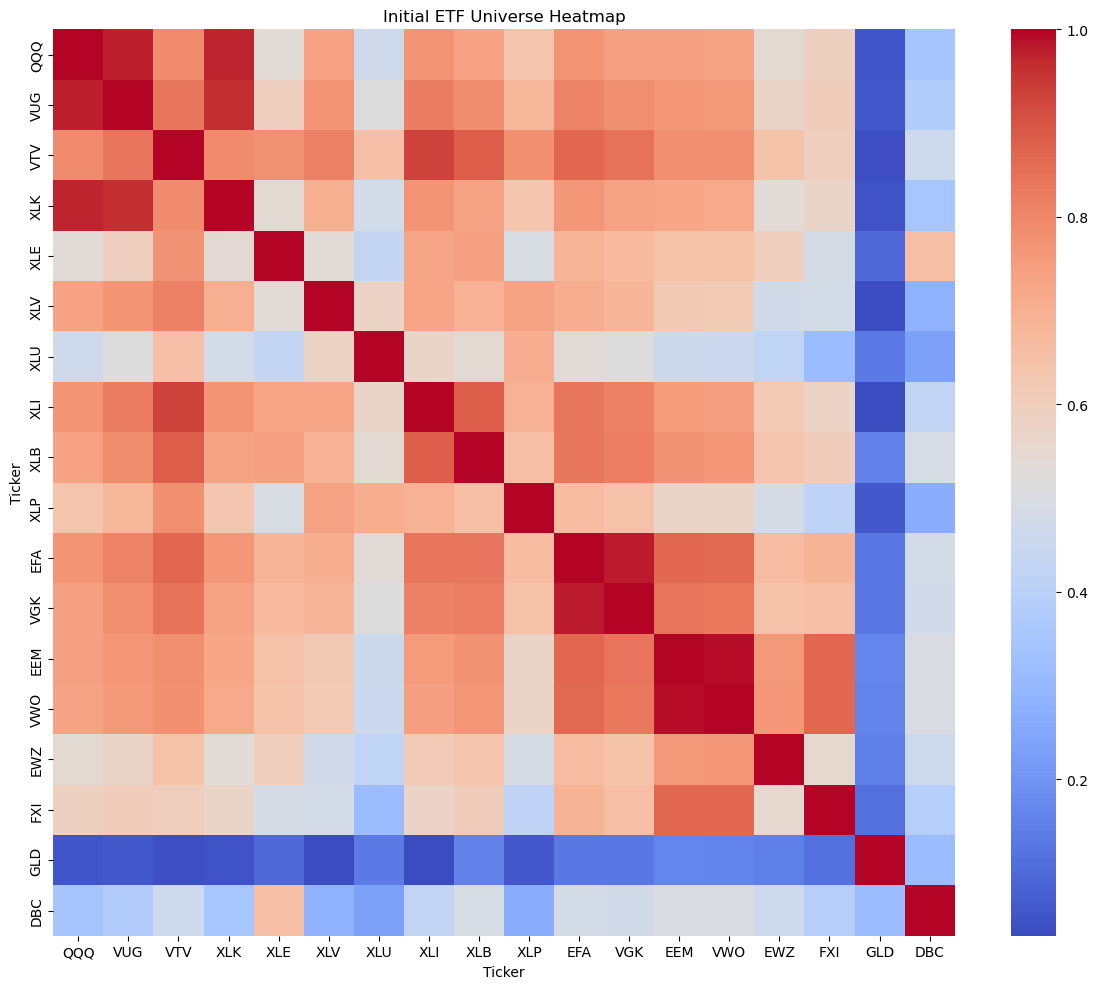

In [46]:
import os

heatmap = plot.plot_correlation_heatmap(matrix)
os.makedirs('results/universe_selection', exist_ok = True)
heatmap.savefig('results/universe_selection/correlation_heatmap.png')

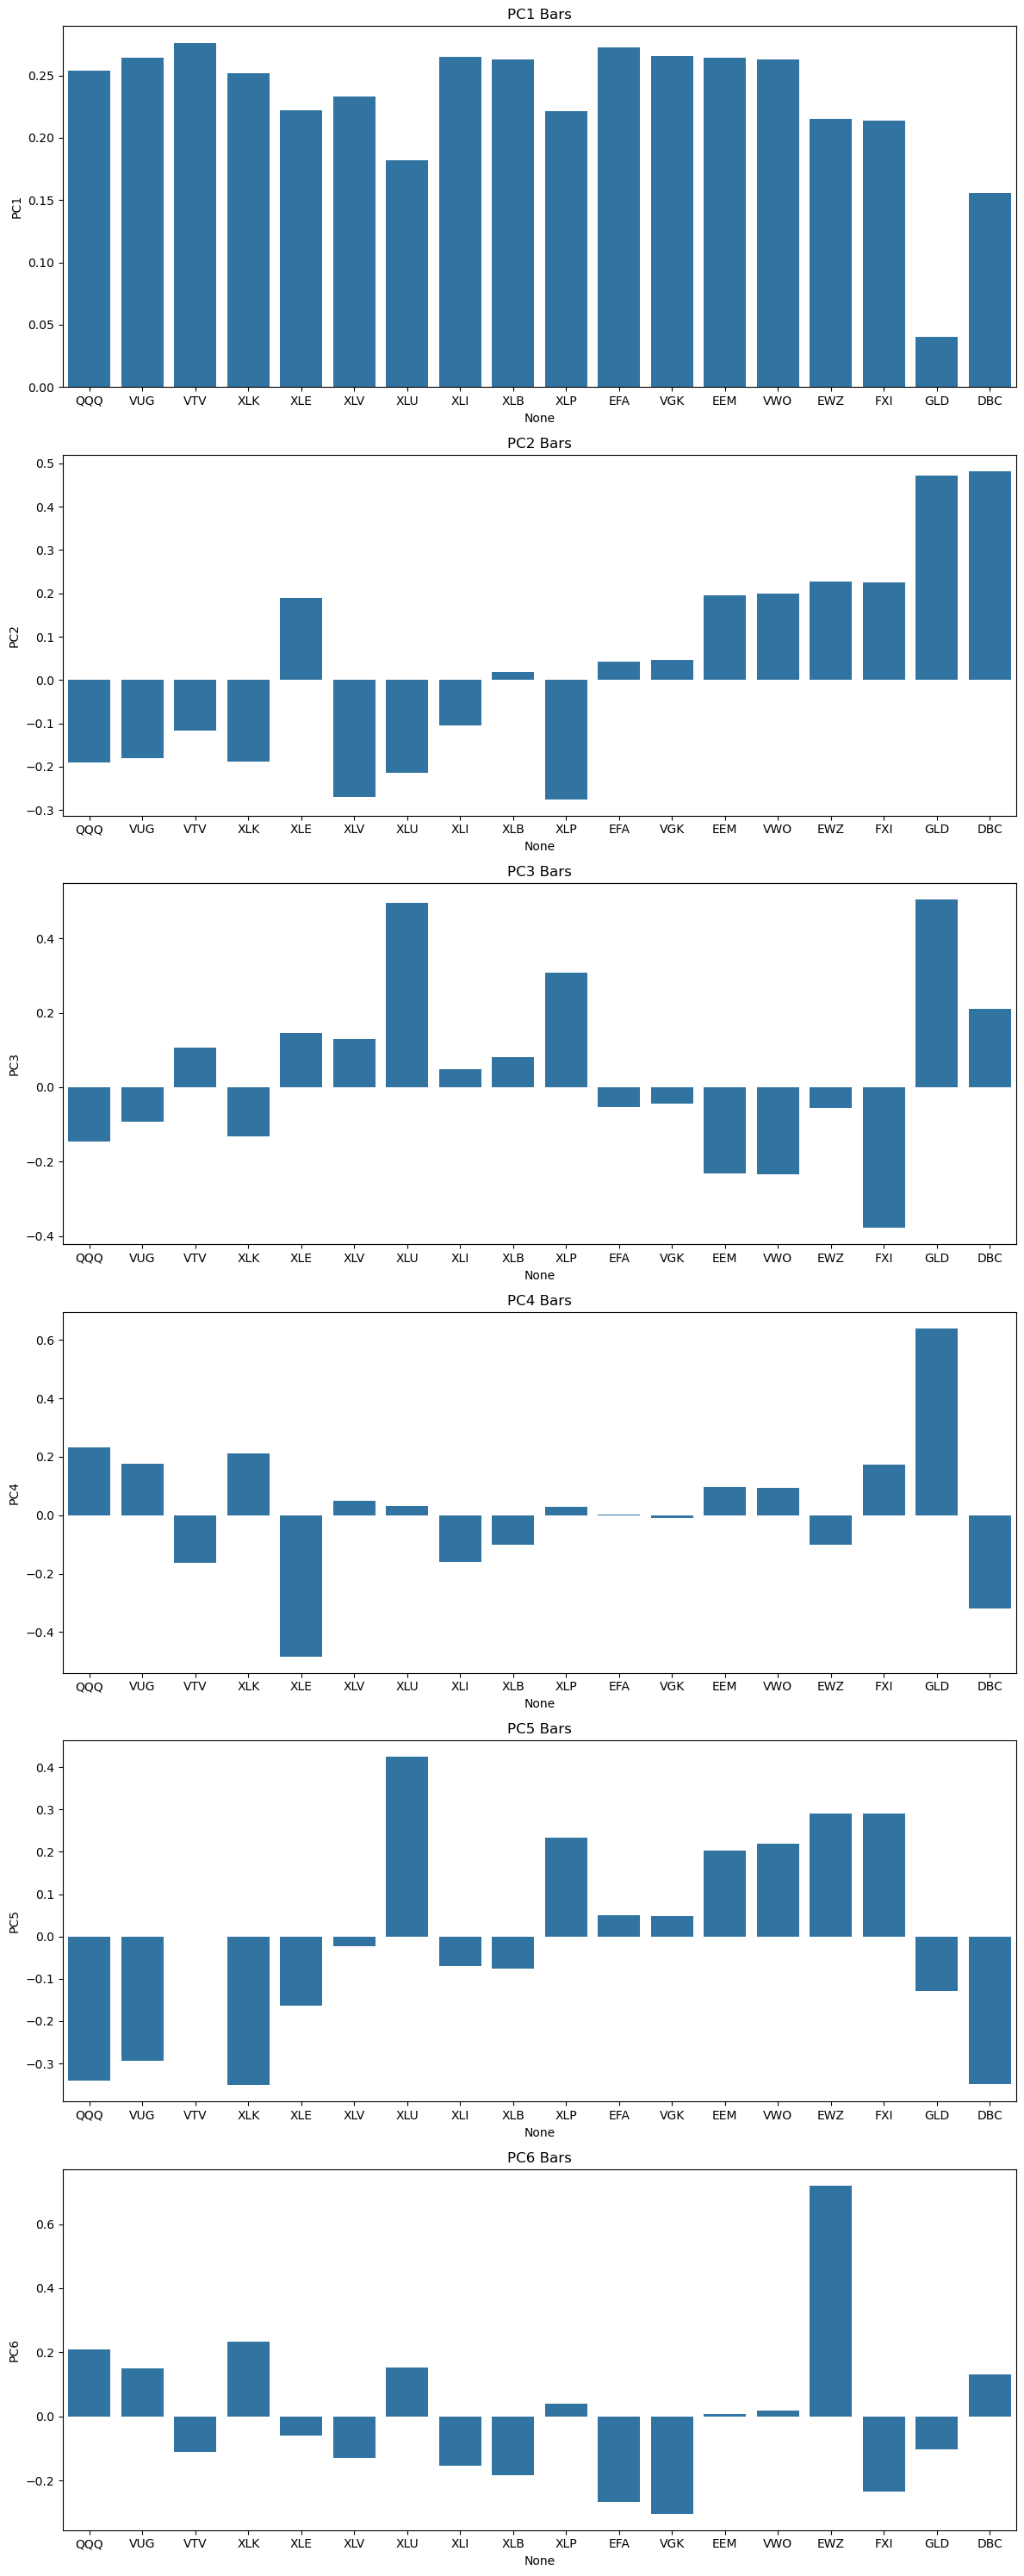

In [47]:
n_comp = pca.significant_components(p_comp)

pca_bars = plot.plot_pca_bars(loadings, n_comp)
os.makedirs('results/universe_selection', exist_ok = True)
pca_bars.savefig('results/universe_selection/pca_bars.png')

In [48]:
import pandas as pd

top_pcas = pca.top_pcas(loadings, n_comp)
top_pcas = correlation.correlation_check(top_pcas, matrix, loadings)
top_pcas.append('SPY')
top_pcas = pd.DataFrame(top_pcas)
top_pcas.to_csv('results/universe_selection/final_assets.csv', index = False)